In [10]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import os
from PIL import Image

In [11]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/skin lesion/0_data/basedata.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   path          10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB


In [12]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(df, groups=df['lesion_id']))

train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]

In [13]:
IMG_SIZE = (224, 224)  
BATCH_SIZE = 64

def load_and_preprocess(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
    return img, label

def make_dataset(dataframe, shuffle=False, augment=False):
    paths = dataframe['path'].values
    labels = dataframe['label'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: load_and_preprocess(p, l, augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True, augment=True)
val_ds = make_dataset(val_df)

print("Classes:", le.classes_)

Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [14]:
base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

In [15]:
n_classes = 7

avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dense(256, activation='relu')(avg)
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

In [16]:
for layer in base_model.layers:
    layer.trainable = False

In [17]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights)}
print(class_weight_dict)

# optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)  
# model.compile(
#     loss="sparse_categorical_crossentropy",
#     optimizer=optimizer,
#     metrics=["accuracy"]
# )

# history = model.fit(
#     train_ds, 
#     validation_data=val_ds,
#     epochs=20,
#     class_weight = class_weight_dict,
#     callbacks=[
#         tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
#         tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
#     ]
# )

{0: 4.390659340659341, 1: 2.6923854447439353, 2: 1.333611481975968, 3: 11.76877761413844, 4: 1.3016777976869196, 5: 0.21262272836122714, 6: 10.57010582010582}


In [18]:
import pickle
# pickle.dump(history.history, open('history.pkl', 'wb'))
history = pickle.load(open('/media/prince/5A4E832F4E83034D/skin lesion/0_models/fine_tune_history.pkl', 'rb'))

# model.save('model.h5')
model = tf.keras.models.load_model('/media/prince/5A4E832F4E83034D/skin lesion/0_models/fine_tune_model.h5')

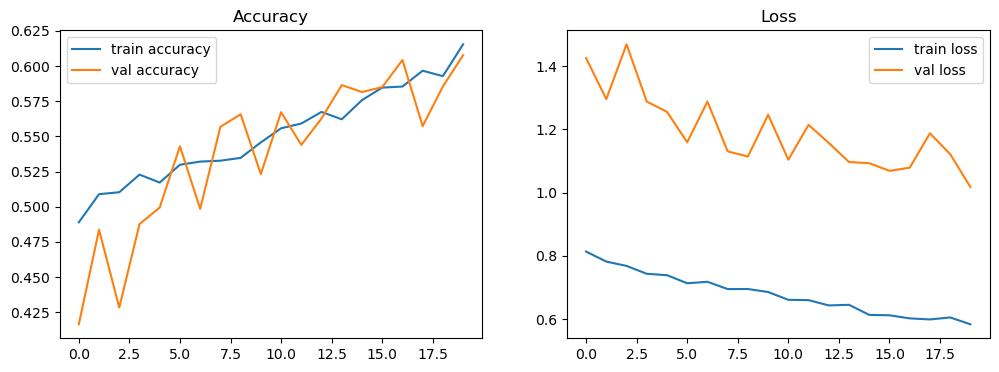

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


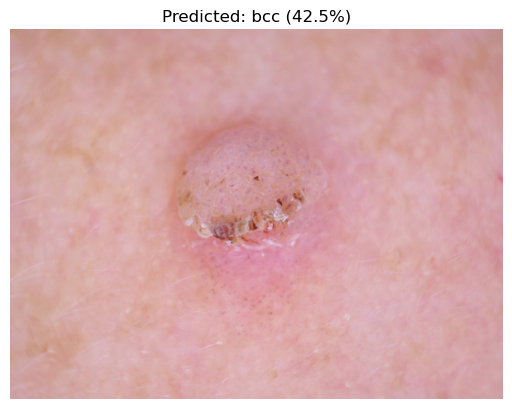

Predicted: bcc
Confidence: 42.5%


In [19]:
# plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='train accuracy')
plt.plot(history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()

plt.show()

# predict on one sample image
import numpy as np
from PIL import Image

class_names = le.classes_  # ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']

def predict_image(img_path):
    img = Image.open(img_path).resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # add batch dimension
    
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    
    plt.imshow(Image.open(img_path))
    plt.title(f'Predicted: {predicted_class} ({confidence:.1f}%)')
    plt.axis('off')
    plt.show()
    
    print(f"Predicted: {predicted_class}")
    print(f"Confidence: {confidence:.1f}%")

# test it
predict_image(val_df['path'].iloc[0])

2026-05-07 15:16:26.333153: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


              precision    recall  f1-score   support

       akiec       0.21      0.88      0.34        67
         bcc       0.38      0.33      0.36        90
         bkl       0.43      0.53      0.48       243
          df       0.09      0.56      0.15        18
         mel       0.37      0.37      0.37       236
          nv       0.91      0.66      0.77      1336
        vasc       0.71      0.85      0.77        34

    accuracy                           0.61      2024
   macro avg       0.44      0.60      0.46      2024
weighted avg       0.73      0.61      0.65      2024



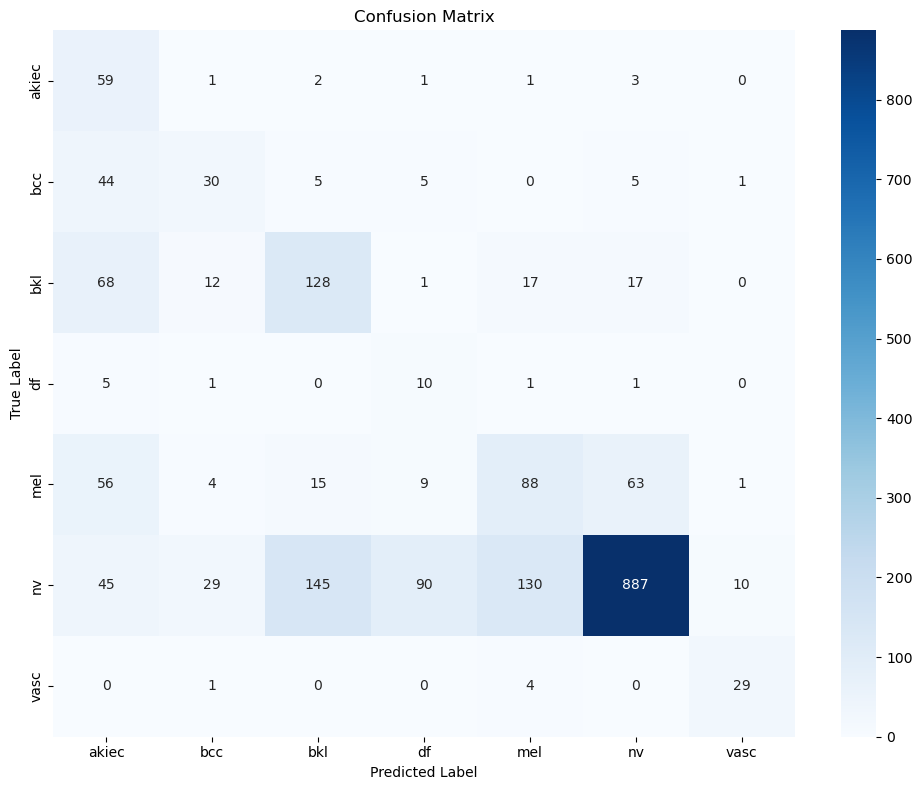

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# get true labels and predictions from val set
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 1. classification report
print(classification_report(y_true, y_pred, target_names=le.classes_))

# 2. confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()